# 03 Feature Analysis — Abnormal Window Explanation

这一份 notebook 承接 `02_baseline_isolation_forest.ipynb` 的结果，目标是回答：

> **末端异常低谷对应的异常窗口，到底在哪些特征上最不一样？**

这里会完成：
1. 读取 baseline 结果表
2. 定义异常窗口 `12115~12135`
3. 对比异常窗口与其他区间的特征差异
4. 计算更完整的特征敏感度指标（均值、标准差、中位数、IQR、effect size）
5. 画关键特征局部图
6. 找出最值得进一步排查的可疑特征，为 `04_vrr12_investigation.ipynb` 做准备


## 0. 导入库

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1800)


## 1. 读取 baseline 结果表

这里直接使用 `02_baseline_isolation_forest.ipynb` 保存出来的结果表，避免重复计算。

In [2]:
data_path = '../outputs/tables/pwr_anomaly_with_scores.csv'
df = pd.read_csv(data_path)

print('结果表形状：', df.shape)
df.head()

结果表形状： (12267, 19)


,Readings,Temperature,Pressure,Flow1,Flow2,VRR12,VRR22,VRR23,VRR33,VRS01,VRS03,VRS21,VRS31,VRS02,VRI01,VRI02,VRI03,anomaly_label,anomaly_score
0,1,248.852987,9.689813,4462.130014,13302.92650,19.060938,0.059119,0.050589,0.111864,0.033951,0.047812,0.232627,0.253775,0.400726,1.763223,0.003031,0.004995,1,0.025588
1,2,269.315740,1.279532,4480.252595,13784.45225,19.062128,0.059089,0.048788,0.111340,0.034060,0.052611,0.233342,0.315067,0.128517,1.769272,0.003164,0.004999,1,0.042263
2,3,94.320644,6.280686,4325.270376,12899.98773,19.061641,0.058145,0.048552,0.111118,0.033859,0.053999,0.233387,0.380191,0.321816,1.768585,0.003321,0.004996,1,0.038870
3,4,271.019823,0.669886,4481.761795,13733.00610,19.062453,0.058236,0.049514,0.112658,0.034049,0.050767,0.233850,0.329846,0.132092,1.772432,0.003061,0.004998,1,0.052052
4,5,207.876262,6.806043,4425.839490,13500.22222,19.061101,0.058378,0.049809,0.111252,0.033996,0.052669,0.233619,0.390729,0.247973,1.772356,0.003060,0.004994,1,0.062089


## 2. 为什么关注 `12115~12135`

在 `02_baseline_isolation_forest.ipynb` 中，已经通过：
- `anomaly_score vs readings` 全局图
- `12050~12267` 局部放大图
- top10 最异常样本

发现末端存在明显连续异常低谷，且最异常样本集中在 `12115~12135` 附近。
因此，这里将该区间定义为**异常窗口**，并与其余样本进行比较。

In [3]:
window_start = 12115
window_end = 12135

window_df = df[(df['Readings'] >= window_start) & (df['Readings'] <= window_end)].copy()
other_df = df[~((df['Readings'] >= window_start) & (df['Readings'] <= window_end))].copy()

print('异常窗口样本数：', window_df.shape)
print('其他区间样本数：', other_df.shape)

异常窗口样本数： (21, 19)
其他区间样本数： (12246, 19)


## 3. 第一版特征均值差异表

先做一个最直观的对比：
- 异常窗口均值
- 其他区间均值
- 绝对差值

这一步的作用是快速粗筛：哪些特征在异常窗口里最不一样。

In [4]:
exclude_cols = ['Readings', 'anomaly_label', 'anomaly_score']
feature_cols = [col for col in df.columns if col not in exclude_cols]

compare_df = pd.DataFrame({
    'window_mean': window_df[feature_cols].mean(),
    'other_mean': other_df[feature_cols].mean()
})

compare_df['abs_diff'] = (compare_df['window_mean'] - compare_df['other_mean']).abs()
compare_df = compare_df.sort_values(by='abs_diff', ascending=False)

print('异常窗口 vs 其余样本 的特征均值差异（按差值排序）：')
display(compare_df)

compare_df.to_csv('../outputs/tables/window_feature_difference.csv')
print('已保存到 ../outputs/tables/window_feature_difference.csv')

异常窗口 vs 其余样本 的特征均值差异（按差值排序）：


,window_mean,other_mean,abs_diff
Flow2,14179.418252,13020.184149,1159.234103
Temperature,288.004319,178.418823,109.585497
VRR12,0.191914,18.682676,18.490762
Flow1,4412.302861,4399.369898,12.932963
Pressure,16.428359,8.331914,8.096445
VRS02,0.079505,0.236377,0.156873
VRS31,0.250111,0.316311,0.066200
VRI01,1.772848,1.767089,0.005758
VRS03,0.047027,0.051057,0.004031
VRS21,0.230690,0.232721,0.002031


已保存到 ../outputs/tables/window_feature_difference.csv


## 4. 更完整的特征敏感度分析

只看均值不够，因为均值无法区分：
- 是整体水平真的变了
- 还是被少数极端值拉偏了

所以这里进一步加入：
- `window_std` / `other_std`
- `window_median` / `other_median`
- `window_iqr` / `other_iqr`
- `effect_size`

这样可以更稳地判断哪些特征是真正敏感的。

In [5]:
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

rows = []

for col in feature_cols:
    window_mean = window_df[col].mean()
    other_mean = other_df[col].mean()
    mean_diff = window_mean - other_mean

    window_std = window_df[col].std()
    other_std = other_df[col].std()
    std_ratio = window_std / (other_std + 1e-8)

    window_median = window_df[col].median()
    other_median = other_df[col].median()
    median_diff = window_median - other_median

    window_iqr = iqr(window_df[col])
    other_iqr = iqr(other_df[col])

    pooled_std = ((window_std ** 2 + other_std ** 2) / 2) ** 0.5
    effect_size = abs(mean_diff) / (pooled_std + 1e-8)

    rows.append({
        'feature': col,
        'window_mean': window_mean,
        'other_mean': other_mean,
        'mean_diff': mean_diff,
        'window_std': window_std,
        'other_std': other_std,
        'std_ratio': std_ratio,
        'window_median': window_median,
        'other_median': other_median,
        'median_diff': median_diff,
        'window_iqr': window_iqr,
        'other_iqr': other_iqr,
        'effect_size': effect_size
    })

feature_compare_df = pd.DataFrame(rows)
feature_compare_df = feature_compare_df.sort_values(by='effect_size', ascending=False)

print('异常窗口 vs 其他区间：更完整的特征敏感度分析')
display(feature_compare_df)

feature_compare_df.to_csv('../outputs/tables/feature_compare_mean_std_median_iqr.csv', index=False)
print('已保存到 ../outputs/tables/feature_compare_mean_std_median_iqr.csv')

异常窗口 vs 其他区间：更完整的特征敏感度分析


,feature,window_mean,other_mean,mean_diff,window_std,other_std,std_ratio,window_median,other_median,median_diff,window_iqr,other_iqr,effect_size
4,VRR12,0.191914,18.682676,-18.490762,1.031351e-04,2.647561,0.000039,0.191935,19.061713,-18.869778,0.000092,0.001055,9.876972
0,Temperature,288.004319,178.418823,109.585497,3.093230e-01,65.007906,0.004758,287.989700,178.881991,109.107710,0.204200,112.308747,2.383949
1,Pressure,16.428359,8.331914,8.096445,2.708371e-01,4.820475,0.056185,16.574980,8.337049,8.237931,0.104830,8.419052,2.371565
12,VRS02,0.079505,0.236377,-0.156873,2.940117e-05,0.093880,0.000313,0.079504,0.234630,-0.155126,0.000047,0.161463,2.363130
9,VRS03,0.047027,0.051057,-0.004031,7.796596e-05,0.002445,0.031885,0.047002,0.051048,-0.004046,0.000082,0.004274,2.329947
6,VRR23,0.051896,0.049999,0.001897,1.489792e-04,0.001252,0.119035,0.051922,0.050027,0.001895,0.000162,0.002171,2.128970
13,VRI01,1.772848,1.767089,0.005758,7.725111e-04,0.003759,0.205531,1.773167,1.767054,0.006113,0.000886,0.006461,2.122230
10,VRS21,0.230690,0.232721,-0.002031,1.942999e-04,0.001351,0.143794,0.230682,0.232698,-0.002016,0.000315,0.002358,2.103858
11,VRS31,0.250111,0.316311,-0.066200,2.451078e-04,0.045483,0.005389,0.250023,0.315820,-0.065797,0.000395,0.079984,2.058357
7,VRR33,0.111310,0.112423,-0.001114,1.399848e-04,0.000755,0.185288,0.111273,0.112432,-0.001159,0.000168,0.001286,2.049545


已保存到 ../outputs/tables/feature_compare_mean_std_median_iqr.csv


## 5. 画关键特征的局部图

这里选 4 个特征做局部窗口分析：
- `Temperature`
- `Pressure`
- `Flow2`
- `VRS02`

其中：
- `Temperature`、`Pressure` 是当前主线最清楚的物理量
- `Flow2` 在统计上偏高
- `VRS02` 用来验证是否存在其他传感器联动变化

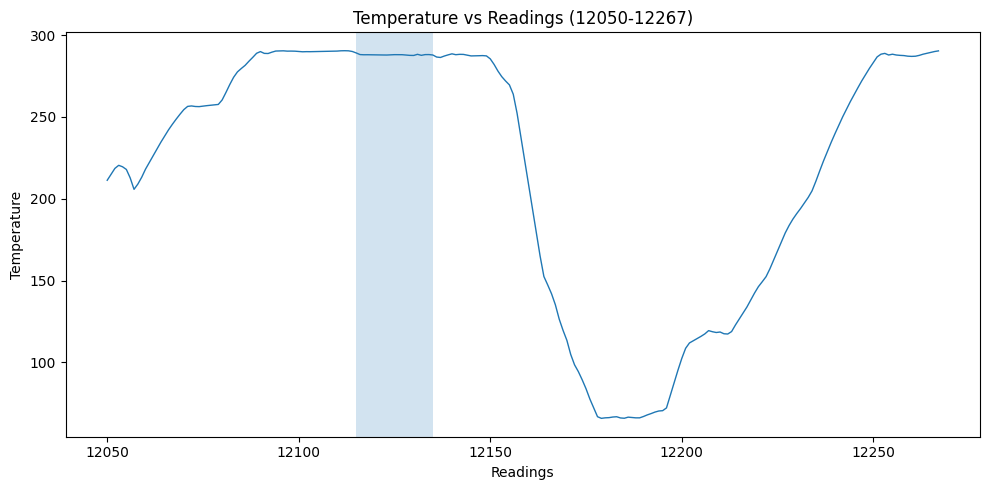

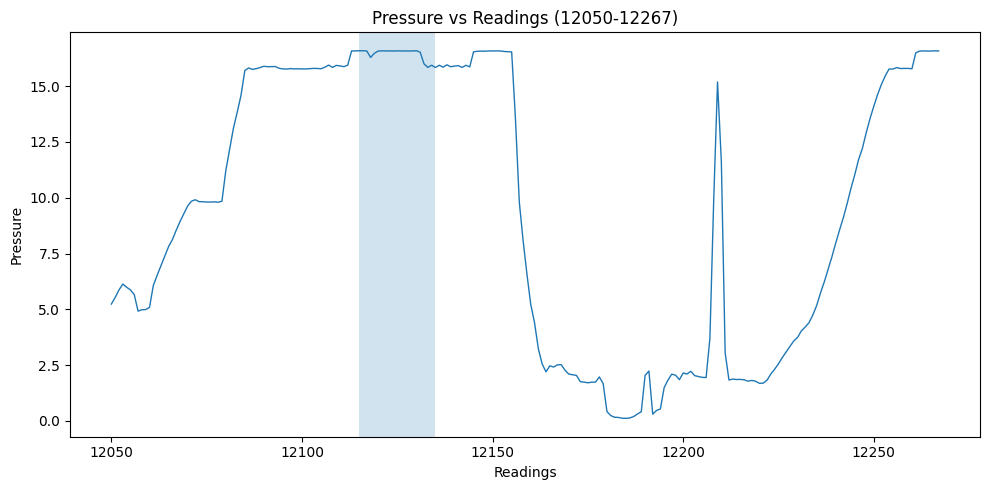

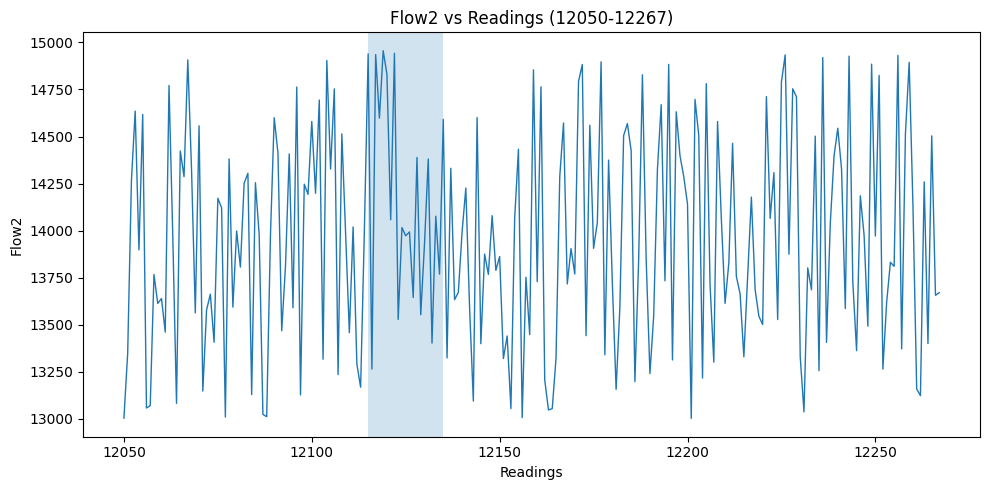

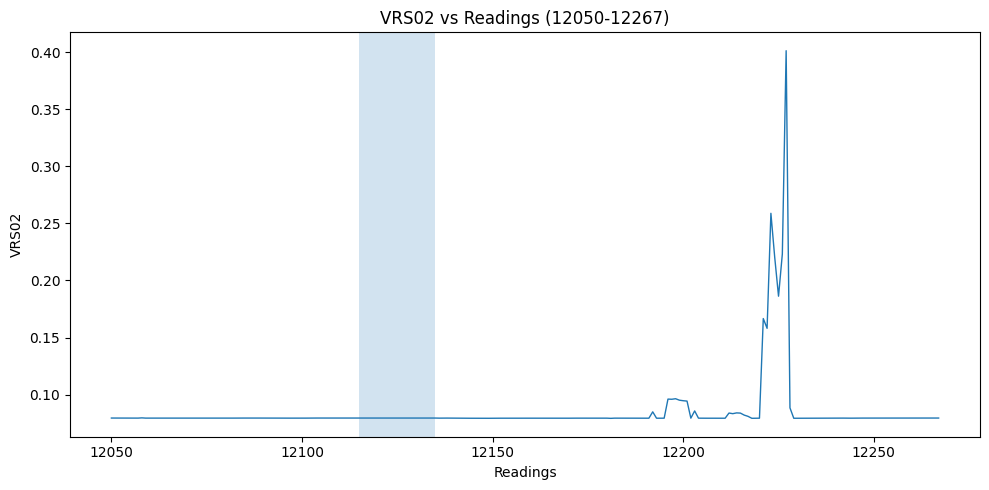

4个关键特征局部图已保存到 ../outputs/figures/


In [6]:
zoom_df = df[(df['Readings'] >= 12050) & (df['Readings'] <= 12267)].copy()
features_to_plot = ['Temperature', 'Pressure', 'Flow2', 'VRS02']

for feature in features_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(zoom_df['Readings'], zoom_df[feature], linewidth=1)
    plt.axvspan(window_start, window_end, alpha=0.2)
    plt.xlabel('Readings')
    plt.ylabel(feature)
    plt.title(f'{feature} vs Readings (12050-12267)')
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{feature.lower()}_zoom_marked.png', dpi=300)
    plt.show()

print('4个关键特征局部图已保存到 ../outputs/figures/')

## 6. 结果解读

### 当前可以确认的现象
- `Temperature`：异常窗口位于高温平台后段
- `Pressure`：异常窗口位于高压平台后段
- `Flow2`：统计上明显偏高，但局部曲线波动较大，更像整体水平抬高，而不是平滑单调变化
- `VRS02`：在当前异常窗口内不算最强主特征，明显波动更多出现在后续区间

### 为什么 `VRR12` 变得很可疑
在更完整的特征敏感度分析中，`VRR12` 的 `effect_size` 远高于其他变量；
并且它的均值差和中位数差都异常大，不像是单纯由少量极端值拉出来的。

这说明：
> `VRR12` 在异常窗口中很可能存在显著且稳定的量级差异，需要单独排查。

## 7. 小结

### 本 notebook 的结论
- 末端异常窗口 `12115~12135` 对应高温高压平台后段
- `Flow2` 在异常窗口整体偏高，但不是最稳定的主解释变量
- `VRR12` 表现出远高于其他特征的差异强度，且具有显著量级变化

### 下一步
下一本 notebook：
**04_vrr12_investigation.ipynb**

将在其中继续排查：
- `VRR12` 更像传感器异常？
- 更像缩放/量纲问题？
- 还是某种状态切换特征？